In [1]:
# Cell 1 — Load, harmonize, and validate 60/120/180-s results.
from __future__ import annotations

import os
import re
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ntsa-robust")

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import font_manager
from scipy import stats


def locate_phase1(start: Path) -> Path:
    """Locate phase1 from the notebook or repository root."""
    marker = Path(
        "results/simplex_projection/summary/"
        "processed_simplex_summary.csv"
    )
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / marker).is_file():
            return candidate
        nested = candidate / "phase1"
        if (nested / marker).is_file():
            return nested
    raise FileNotFoundError("Could not locate phase1.")


def require(condition: bool, message: str) -> None:
    """Fail loudly when an integrity condition is not met."""
    if not condition:
        raise AssertionError(message)


def normalize_session(series: pd.Series) -> pd.Series:
    """Convert sample_01/session_01/integer identifiers to integers."""
    extracted = series.astype(str).str.extract(r"(\d+)$", expand=False)
    require(extracted.notna().all(), "Unrecognized session identifier.")
    return pd.to_numeric(extracted, errors="raise").astype(int)


def strict_bool(series: pd.Series) -> pd.Series:
    """Parse a saved Boolean field without truthy-string ambiguity."""
    values = series.astype(str).str.strip().str.casefold()
    truthy = {"true", "1", "1.0", "yes", "pass", "included"}
    falsy = {"false", "0", "0.0", "no", "fail", "excluded"}
    require(values.isin(truthy | falsy).all(), f"Invalid {series.name}.")
    return values.isin(truthy)


PHASE1_DIR = locate_phase1(Path.cwd())
OUTPUT_DIR = PHASE1_DIR / "outputs" / "robust_window"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DURATIONS = (60, 120, 180)
STATES = ("Awake", "Drowsy")
METRICS = ("Mean_CC", "Mean_NRMSE", "DET", "LLE")
EXPECTED_SESSIONS = 20
EXPECTED_SIGN = {
    "Mean_CC": -1,
    "Mean_NRMSE": 1,
    "DET": -1,
    "LLE": -1,
}
SOURCE_DOMAIN = {
    "Mean_CC": "Prediction",
    "Mean_NRMSE": "Prediction",
    "DET": "RQA",
    "LLE": "LLE",
}

# Prediction: median across windows at each frozen horizon, then
# arithmetic mean across the same 18 horizons.
prediction_path = (
    PHASE1_DIR
    / "results"
    / "simplex_projection"
    / "summary"
    / "processed_simplex_summary.csv"
)
prediction = pd.read_csv(prediction_path)
prediction_required = {
    "session", "state", "representation", "window_size_s",
    "horizon_seconds", "median_cc", "median_nrmse", "n_windows",
}
require(
    prediction_required.issubset(prediction.columns),
    "Prediction schema is incomplete.",
)
prediction = prediction.loc[
    prediction["representation"].str.casefold().eq("processed")
    & prediction["window_size_s"].isin(DURATIONS)
    & prediction["state"].isin(STATES)
].copy()
prediction["session"] = normalize_session(prediction["session"])
prediction_key = [
    "session", "state", "window_size_s", "horizon_seconds"
]
require(
    not prediction.duplicated(prediction_key).any(),
    "Duplicate prediction session-state-duration-horizon rows.",
)
prediction_numeric = prediction[
    ["horizon_seconds", "median_cc", "median_nrmse", "n_windows"]
].to_numpy(dtype=float)
require(np.isfinite(prediction_numeric).all(), "Non-finite prediction data.")
horizon_grids = prediction.groupby("window_size_s")["horizon_seconds"].apply(
    lambda values: tuple(sorted(values.unique()))
)
require(
    horizon_grids.nunique() == 1 and len(horizon_grids.iloc[0]) == 18,
    "Prediction horizon grid is not frozen across durations.",
)
prediction_cells = prediction.groupby(
    ["session", "state", "window_size_s"]
)
require(
    prediction_cells["horizon_seconds"].nunique().eq(18).all(),
    "A prediction cell has incomplete horizons.",
)
require(
    prediction_cells["n_windows"].nunique().eq(1).all(),
    "Prediction window counts vary across horizons.",
)
prediction_state = prediction_cells.agg(
    Mean_CC=("median_cc", "mean"),
    Mean_NRMSE=("median_nrmse", "mean"),
    n_windows=("n_windows", "first"),
).reset_index().rename(columns={"window_size_s": "duration_s"})
prediction_long = prediction_state.melt(
    id_vars=["session", "state", "duration_s", "n_windows"],
    value_vars=["Mean_CC", "Mean_NRMSE"],
    var_name="metric",
    value_name="value",
)

# RQA: session-state median DET from Processed windows only.
rqa_path = PHASE1_DIR / "results" / "rqa" / "rqa_window_level.csv"
rqa = pd.read_csv(rqa_path)
rqa_required = {
    "session", "state", "representation", "window_size",
    "window_id", "fs", "tau_samples", "theiler_samples",
    "target_rr", "achieved_rr", "DET",
}
require(rqa_required.issubset(rqa.columns), "RQA schema is incomplete.")
rqa = rqa.loc[
    rqa["representation"].str.casefold().eq("processed")
    & rqa["window_size"].isin(DURATIONS)
    & rqa["state"].isin(STATES)
].copy()
rqa["session"] = normalize_session(rqa["session"])
rqa_key = ["session", "state", "window_size", "window_id"]
require(not rqa.duplicated(rqa_key).any(), "Duplicate RQA window rows.")
require(np.isfinite(rqa["DET"]).all(), "Non-finite DET values.")
require(
    np.allclose(rqa["target_rr"], 0.02),
    "RQA target recurrence rate is not frozen at 0.02.",
)
rqa_session_config = rqa.groupby("session")[
    ["fs", "tau_samples", "theiler_samples"]
].nunique()
require(
    rqa_session_config.le(1).all().all(),
    "RQA session-specific configuration changes across durations.",
)
rqa_state = (
    rqa.groupby(["session", "state", "window_size"], as_index=False)
    .agg(value=("DET", "median"), n_windows=("window_id", "size"))
    .rename(columns={"window_size": "duration_s"})
)
rqa_state["metric"] = "DET"

# LLE: same primary QC at every duration (R2 >= 0.90).
lle_dir = PHASE1_DIR / "results" / "lle" / "processed"
lle_paths = sorted(lle_dir.glob("session_*_processed_rosenstein_lle.csv"))
require(len(lle_paths) == EXPECTED_SESSIONS, "Expected 20 LLE files.")
lle = pd.concat([pd.read_csv(path) for path in lle_paths], ignore_index=True)
lle_required = {
    "session", "state", "window_size_s", "window_id",
    "representation", "m", "tau_s", "fit_start_s",
    "fit_end_s", "lle_1_per_s", "fit_r2",
    "analysis_included", "signal_finite", "valid",
}
require(lle_required.issubset(lle.columns), "LLE schema is incomplete.")
lle = lle.loc[
    lle["representation"].str.casefold().eq("processed")
    & lle["window_size_s"].isin(DURATIONS)
    & lle["state"].isin(STATES)
].copy()
lle["session"] = normalize_session(lle["session"])
lle_key = ["session", "state", "window_size_s", "window_id"]
require(not lle.duplicated(lle_key).any(), "Duplicate LLE window rows.")
require(np.allclose(lle["m"], 8), "LLE m is not frozen at 8.")
require(np.allclose(lle["tau_s"], 0.16), "LLE tau is not 0.16 s.")
require(
    np.allclose(lle["fit_start_s"], 0.80)
    and np.allclose(lle["fit_end_s"], 1.30),
    "LLE fit interval differs from 0.80-1.30 s.",
)
lle_included = strict_bool(lle["analysis_included"])
lle_finite_signal = strict_bool(lle["signal_finite"])
lle_finite = np.isfinite(
    lle[["lle_1_per_s", "fit_r2"]].to_numpy(dtype=float)
).all(axis=1)
lle_primary_qc = (
    lle_included & lle_finite_signal & lle_finite & lle["fit_r2"].ge(0.90)
)
require(
    strict_bool(lle["valid"]).eq(lle_primary_qc).all(),
    "Saved LLE validity differs from the frozen R2 >= 0.90 QC.",
)
lle_valid = lle.loc[lle_primary_qc].copy()
lle_state = (
    lle_valid.groupby(
        ["session", "state", "window_size_s"], as_index=False
    )
    .agg(
        value=("lle_1_per_s", "median"),
        n_windows=("window_id", "size"),
    )
    .rename(columns={"window_size_s": "duration_s"})
)
lle_state["metric"] = "LLE"

# The Prediction and RQA domains must refer to the same Processed windows.
prediction_counts = prediction_state[
    ["session", "state", "duration_s", "n_windows"]
]
rqa_counts = rqa_state[
    ["session", "state", "duration_s", "n_windows"]
]
count_check = prediction_counts.merge(
    rqa_counts,
    on=["session", "state", "duration_s"],
    suffixes=("_prediction", "_rqa"),
    validate="one_to_one",
)
require(
    count_check["n_windows_prediction"].eq(
        count_check["n_windows_rqa"]
    ).all(),
    "Prediction and RQA window counts are not harmonized.",
)

session_state_long = pd.concat(
    [
        prediction_long,
        rqa_state[["session", "state", "duration_s",
                   "n_windows", "metric", "value"]],
        lle_state[["session", "state", "duration_s",
                   "n_windows", "metric", "value"]],
    ],
    ignore_index=True,
)
state_key = ["session", "state", "duration_s", "metric"]
require(
    not session_state_long.duplicated(state_key).any(),
    "Duplicate session-state-duration-metric rows.",
)
require(
    np.isfinite(session_state_long["value"]).all(),
    "Non-finite session-state metrics.",
)
coverage = session_state_long.groupby(["metric", "duration_s"])[
    ["session", "state"]
].nunique()
require(
    coverage["session"].eq(EXPECTED_SESSIONS).all()
    and coverage["state"].eq(len(STATES)).all(),
    "Incomplete session/state coverage.",
)
value_wide = session_state_long.pivot(
    index=["session", "duration_s", "metric"],
    columns="state",
    values="value",
).reindex(columns=STATES)
window_wide = session_state_long.pivot(
    index=["session", "duration_s", "metric"],
    columns="state",
    values="n_windows",
).reindex(columns=STATES)
require(
    value_wide.notna().all().all() and window_wide.notna().all().all(),
    "An Awake-Drowsy pair is incomplete.",
)
session_deltas = value_wide.reset_index().rename(
    columns={"Awake": "awake", "Drowsy": "drowsy"}
)
session_deltas["delta_drowsy_minus_awake"] = (
    session_deltas["drowsy"] - session_deltas["awake"]
)
window_pairs = window_wide.reset_index().rename(
    columns={
        "Awake": "n_windows_awake",
        "Drowsy": "n_windows_drowsy",
    }
)
session_deltas = session_deltas.merge(
    window_pairs,
    on=["session", "duration_s", "metric"],
    validate="one_to_one",
)
session_deltas["source_domain"] = session_deltas["metric"].map(
    SOURCE_DOMAIN
)
session_deltas["expected_sign"] = session_deltas["metric"].map(
    EXPECTED_SIGN
)
session_deltas["in_expected_direction"] = (
    np.sign(session_deltas["delta_drowsy_minus_awake"])
    == session_deltas["expected_sign"]
)
metric_order = {metric: index for index, metric in enumerate(METRICS)}
session_deltas["_metric_order"] = session_deltas["metric"].map(
    metric_order
)
session_deltas = (
    session_deltas.sort_values(["_metric_order", "duration_s", "session"])
    .drop(columns="_metric_order")
    .reset_index(drop=True)
)
require(len(session_deltas) == 240, "Expected 4 x 3 x 20 deltas.")
session_delta_path = OUTPUT_DIR / "robust_window_session_deltas.csv"
session_deltas.to_csv(session_delta_path, index=False)
lle_qc_counts = lle.assign(qc_valid=lle_primary_qc).groupby(
    "window_size_s"
)["qc_valid"].agg(["size", "sum"])
lle_qc_counts["excluded"] = (
    lle_qc_counts["size"] - lle_qc_counts["sum"]
)
print("Sources: Prediction summary, RQA windows, and LLE Processed files.")
print("Metric definitions/configuration frozen across 60/120/180 s: PASS")
print("Coverage: 20 paired sessions for every metric and duration: PASS")
print("LLE primary QC (R2 >= 0.90) by duration:")
display(lle_qc_counts)
display(coverage)
print(f"Saved: {session_delta_path}")


Sources: Prediction summary, RQA windows, and LLE Processed files.
Metric definitions/configuration frozen across 60/120/180 s: PASS
Coverage: 20 paired sessions for every metric and duration: PASS
LLE primary QC (R2 >= 0.90) by duration:


,size,sum,excluded
window_size_s,,,
60,901,872,29
120,405,399,6
180,238,237,1


session  state
metric     duration_s                
DET        60               20      2
           120              20      2
           180              20      2
LLE        60               20      2
           120              20      2
           180              20      2
Mean_CC    60               20      2
           120              20      2
           180              20      2
Mean_NRMSE 60               20      2
           120              20      2
           180              20      2

Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_session_deltas.csv


In [2]:
# Cell 2 — Statistical robustness summary.
BOOTSTRAP_RESAMPLES = 20_000
BOOTSTRAP_SEED = 20260831
ZERO_TOLERANCE = 1e-12


def bootstrap_median_ci(
    values: np.ndarray, seed: int
) -> tuple[float, float]:
    """Return a percentile-bootstrap CI for the paired median."""
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    indices = rng.integers(
        0, len(values), size=(BOOTSTRAP_RESAMPLES, len(values))
    )
    medians = np.median(values[indices], axis=1)
    low, high = np.percentile(medians, [2.5, 97.5])
    return float(low), float(high)


def paired_rank_biserial(values: np.ndarray) -> float:
    """Return matched-pairs signed-rank rank-biserial effect size."""
    values = np.asarray(values, dtype=float)
    nonzero = values[
        ~np.isclose(values, 0.0, atol=ZERO_TOLERANCE, rtol=0.0)
    ]
    if nonzero.size == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(nonzero), method="average")
    positive = ranks[nonzero > 0.0].sum()
    negative = ranks[nonzero < 0.0].sum()
    return float((positive - negative) / (positive + negative))


summary_rows = []
for metric_index, metric in enumerate(METRICS):
    for duration_index, duration in enumerate(DURATIONS):
        group = session_deltas.loc[
            session_deltas["metric"].eq(metric)
            & session_deltas["duration_s"].eq(duration)
        ].sort_values("session")
        require(
            len(group) == EXPECTED_SESSIONS,
            f"Incomplete inference group: {metric}, {duration} s.",
        )
        delta = group["delta_drowsy_minus_awake"].to_numpy(dtype=float)
        ci_low, ci_high = bootstrap_median_ci(
            delta, BOOTSTRAP_SEED + metric_index * 10 + duration_index
        )
        nonzero = delta[
            ~np.isclose(delta, 0.0, atol=ZERO_TOLERANCE, rtol=0.0)
        ]
        if nonzero.size == 0:
            statistic, p_value = 0.0, 1.0
        else:
            test = stats.wilcoxon(
                nonzero,
                zero_method="wilcox",
                correction=False,
                alternative="two-sided",
                method="auto",
            )
            statistic = float(test.statistic)
            p_value = float(test.pvalue)
        summary_rows.append(
            {
                "metric": metric,
                "duration_s": duration,
                "n_paired_sessions": len(delta),
                "awake_median": float(group["awake"].median()),
                "drowsy_median": float(group["drowsy"].median()),
                "median_delta": float(np.median(delta)),
                "ci95_low": ci_low,
                "ci95_high": ci_high,
                "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
                "bootstrap_seed": (
                    BOOTSTRAP_SEED + metric_index * 10 + duration_index
                ),
                "wilcoxon_statistic": statistic,
                "raw_p_value": p_value,
                "rank_biserial_r_rb": paired_rank_biserial(delta),
                "n_positive": int(np.count_nonzero(delta > 0.0)),
                "n_negative": int(np.count_nonzero(delta < 0.0)),
                "n_zero": int(np.count_nonzero(delta == 0.0)),
            }
        )
robust_summary = pd.DataFrame(summary_rows)
robust_summary["expected_sign"] = robust_summary["metric"].map(
    EXPECTED_SIGN
)
robust_summary["median_in_expected_direction"] = (
    np.sign(robust_summary["median_delta"])
    == robust_summary["expected_sign"]
)
robust_summary["ci_on_expected_side"] = np.where(
    robust_summary["expected_sign"].gt(0),
    robust_summary["ci95_low"].gt(0),
    robust_summary["ci95_high"].lt(0),
)
for metric in METRICS:
    metric_mask = robust_summary["metric"].eq(metric)
    metric_rows = robust_summary.loc[metric_mask].set_index("duration_s")
    median_signs = np.sign(metric_rows.loc[list(DURATIONS), "median_delta"])
    direction_preserved = (
        np.all(median_signs != 0) and len(set(median_signs)) == 1
    )
    expected_preserved = bool(
        metric_rows.loc[list(DURATIONS),
                        "median_in_expected_direction"].all()
    )
    metric_deltas = session_deltas.loc[
        session_deltas["metric"].eq(metric)
    ].pivot(
        index="session",
        columns="duration_s",
        values="delta_drowsy_minus_awake",
    ).reindex(columns=DURATIONS)
    require(
        metric_deltas.shape == (EXPECTED_SESSIONS, len(DURATIONS))
        and metric_deltas.notna().all().all(),
        f"Incomplete cross-duration session matrix for {metric}.",
    )
    same_sign_sessions = int(
        (np.sign(metric_deltas).eq(EXPECTED_SIGN[metric])).all(axis=1).sum()
    )
    delta_60 = float(metric_rows.loc[60, "median_delta"])
    require(
        not np.isclose(delta_60, 0.0, atol=ZERO_TOLERANCE),
        f"Undefined magnitude ratio for {metric}.",
    )
    ci_consistent = bool(
        metric_rows.loc[list(DURATIONS), "ci_on_expected_side"].all()
    )
    robust_summary.loc[metric_mask, "Direction_preserved"] = (
        direction_preserved
    )
    robust_summary.loc[metric_mask, "Expected_direction_preserved"] = (
        expected_preserved
    )
    robust_summary.loc[
        metric_mask, "Sessions_same_sign_all_durations"
    ] = same_sign_sessions
    robust_summary.loc[metric_mask, "CI_direction_consistency"] = (
        ci_consistent
    )
    robust_summary.loc[metric_mask, "magnitude_ratio_vs_60"] = (
        robust_summary.loc[metric_mask, "median_delta"].abs()
        / abs(delta_60)
    )
robust_summary["Sessions_same_sign_all_durations"] = robust_summary[
    "Sessions_same_sign_all_durations"
].astype(int)
summary_path = OUTPUT_DIR / "robust_window_summary.csv"
robust_summary.to_csv(summary_path, index=False)
print("Raw p-values are descriptive robustness checks only.")
print("No BH-FDR was applied or added to the primary 60-s family.")
display(robust_summary)
print(f"Saved: {summary_path}")


Raw p-values are descriptive robustness checks only.
No BH-FDR was applied or added to the primary 60-s family.


,metric,duration_s,n_paired_sessions,awake_median,drowsy_median,median_delta,ci95_low,ci95_high,bootstrap_resamples,bootstrap_seed,...,n_negative,n_zero,expected_sign,median_in_expected_direction,ci_on_expected_side,Direction_preserved,Expected_direction_preserved,Sessions_same_sign_all_durations,CI_direction_consistency,magnitude_ratio_vs_60
0,Mean_CC,60,20,0.689007,0.663472,-0.033871,-0.059465,-0.004348,20000,20260831,...,15,0,-1,True,True,True,True,14,True,1.000000
1,Mean_CC,120,20,0.695147,0.670488,-0.027124,-0.049042,-0.015585,20000,20260832,...,16,0,-1,True,True,True,True,14,True,0.800821
2,Mean_CC,180,20,0.704790,0.678568,-0.042767,-0.051641,-0.013331,20000,20260833,...,15,0,-1,True,True,True,True,14,True,1.262671
3,Mean_NRMSE,60,20,0.639154,0.665732,0.029424,0.004651,0.053021,20000,20260841,...,5,0,1,True,True,True,True,15,True,1.000000
4,Mean_NRMSE,120,20,0.624684,0.652512,0.032075,0.019613,0.049531,20000,20260842,...,5,0,1,True,True,True,True,15,True,1.090122
5,Mean_NRMSE,180,20,0.617632,0.644588,0.032095,0.018647,0.046484,20000,20260843,...,5,0,1,True,True,True,True,15,True,1.090784
6,DET,60,20,0.712615,0.698349,-0.018645,-0.036354,-0.006899,20000,20260851,...,15,0,-1,True,True,True,True,14,False,1.000000
7,DET,120,20,0.709005,0.691941,-0.020089,-0.039937,-0.013409,20000,20260852,...,15,0,-1,True,True,True,True,14,False,1.077470
8,DET,180,20,0.704044,0.688446,-0.024811,-0.041645,0.000801,20000,20260853,...,14,0,-1,True,False,True,True,14,False,1.330742
9,LLE,60,20,0.810912,0.794717,-0.037570,-0.053698,-0.022976,20000,20260861,...,16,0,-1,True,True,True,True,15,True,1.000000


Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_summary.csv


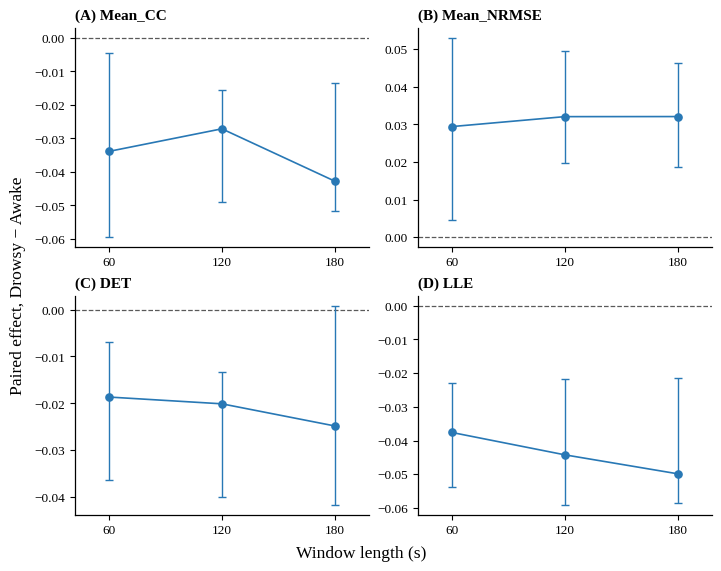

Saved PDF/SVG/PNG (600 dpi) using Liberation Serif: robust_window_primary_metrics.pdf


In [3]:
# Cell 3 — Publication figure for window-size robustness.
def select_serif_font() -> str:
    """Use Times New Roman or the closest available serif fallback."""
    available = {font.name for font in font_manager.fontManager.ttflist}
    for family in ("Times New Roman", "Liberation Serif", "DejaVu Serif"):
        if family in available:
            return family
    return "serif"


PLOT_FONT = select_serif_font()
mpl.rcParams.update(
    {
        "font.family": PLOT_FONT,
        "font.size": 10.5,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.9,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
)
panel_labels = ("(A)", "(B)", "(C)", "(D)")
fig, axes = plt.subplots(
    2, 2, figsize=(7.10, 5.60), constrained_layout=True
)
for axis, metric, panel in zip(axes.flat, METRICS, panel_labels):
    rows = (
        robust_summary.loc[robust_summary["metric"].eq(metric)]
        .set_index("duration_s")
        .loc[list(DURATIONS)]
    )
    estimates = rows["median_delta"].to_numpy(dtype=float)
    errors = np.vstack(
        [
            estimates - rows["ci95_low"].to_numpy(dtype=float),
            rows["ci95_high"].to_numpy(dtype=float) - estimates,
        ]
    )
    axis.axhline(0.0, color="0.35", linestyle="--", linewidth=0.9)
    axis.errorbar(
        DURATIONS,
        estimates,
        yerr=errors,
        color="#2878B5",
        marker="o",
        markersize=5.2,
        linewidth=1.2,
        elinewidth=1.0,
        capsize=3.0,
        zorder=3,
    )
    axis.set_xticks(DURATIONS, [str(duration) for duration in DURATIONS])
    axis.set_title(f"{panel} {metric}", loc="left", fontweight="bold")
    axis.margins(x=0.15)
fig.supxlabel("Window length (s)")
fig.supylabel("Paired effect, Drowsy − Awake")
figure_pdf = OUTPUT_DIR / "robust_window_primary_metrics.pdf"
figure_svg = OUTPUT_DIR / "robust_window_primary_metrics.svg"
figure_png = OUTPUT_DIR / "robust_window_primary_metrics.png"
fig.savefig(figure_pdf, bbox_inches="tight")
fig.savefig(figure_svg, bbox_inches="tight")
fig.savefig(figure_png, dpi=600, bbox_inches="tight")
plt.show()
print(
    f"Saved PDF/SVG/PNG (600 dpi) using {PLOT_FONT}: "
    f"{figure_pdf.name}"
)


In [4]:
# Cell 4 — Compact table and final robustness interpretation.
def format_delta_ci(row: pd.Series) -> str:
    """Format one median effect and bootstrap interval."""
    return (
        f"{row['median_delta']:.4f} "
        f"[{row['ci95_low']:.4f}, {row['ci95_high']:.4f}]"
    )


compact_rows = []
for metric in METRICS:
    rows = (
        robust_summary.loc[robust_summary["metric"].eq(metric)]
        .set_index("duration_s")
        .loc[list(DURATIONS)]
    )
    compact_rows.append(
        {
            "Metric": metric,
            "60 s Delta [95% CI]": format_delta_ci(rows.loc[60]),
            "120 s Delta [95% CI]": format_delta_ci(rows.loc[120]),
            "180 s Delta [95% CI]": format_delta_ci(rows.loc[180]),
            "Direction preserved": (
                "Yes" if rows["Direction_preserved"].iloc[0] else "No"
            ),
            "Same-sign sessions": (
                f"{int(rows['Sessions_same_sign_all_durations'].iloc[0])}"
                f"/{EXPECTED_SESSIONS}"
            ),
        }
    )
compact_table = pd.DataFrame(compact_rows)
compact_path = OUTPUT_DIR / "robust_window_final_evidence.csv"
compact_table.to_csv(compact_path, index=False)
all_expected = bool(
    robust_summary.groupby("metric")[
        "Expected_direction_preserved"
    ].first().all()
)
all_ci_consistent = bool(
    robust_summary.groupby("metric")[
        "CI_direction_consistency"
    ].first().all()
)
if all_expected and all_ci_consistent:
    stability = "stable"
    dependence = "not critically dependent"
elif all_expected:
    stability = "partially stable"
    dependence = "not directionally dependent"
else:
    stability = "unstable"
    dependence = "partially dependent"
direction_wording = "preserved" if all_expected else "not preserved"
metric_lines = []
for metric in METRICS:
    rows = (
        robust_summary.loc[robust_summary["metric"].eq(metric)]
        .set_index("duration_s")
        .loc[list(DURATIONS)]
    )
    metric_lines.append(
        f"- {metric}: median Delta "
        f"{rows.loc[60, 'median_delta']:.4f}, "
        f"{rows.loc[120, 'median_delta']:.4f}, and "
        f"{rows.loc[180, 'median_delta']:.4f} at 60, 120, and 180 s; "
        f"same expected sign in "
        f"{int(rows['Sessions_same_sign_all_durations'].iloc[0])}"
        f"/{EXPECTED_SESSIONS} sessions."
    )
conclusion = "\n".join(
    [
        "## Window-size robustness — Final interpretation",
        "",
        "The primary Awake–Drowsy effects were re-evaluated at "
        "120-s and 180-s window lengths.",
        "",
        *metric_lines,
        "",
        f"Across the four headline metrics, the direction of the 60-s "
        f"effect was {direction_wording} at both longer window sizes.",
        "",
        f"Effect directions and bootstrap confidence intervals showed "
        f"{stability} behavior across durations.",
        "",
        f"These results indicate that the primary 60-s findings are "
        f"{dependence} on the selected window length.",
        "",
        "The 120-s and 180-s analyses are strictly robustness checks; "
        "60 s remains the predefined primary temporal scale. Raw "
        "robustness p-values were not added to the primary BH-FDR family.",
    ]
)
conclusion_path = OUTPUT_DIR / "robust_window_conclusion.md"
conclusion_path.write_text(conclusion + "\n", encoding="utf-8")
print(f"Saved: {compact_path} and {conclusion_path}")
display(compact_table)
display(Markdown(conclusion))


Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_final_evidence.csv and /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_conclusion.md


,Metric,60 s Delta [95% CI],120 s Delta [95% CI],180 s Delta [95% CI],Direction preserved,Same-sign sessions
0,Mean_CC,"-0.0339 [-0.0595, -0.0043]","-0.0271 [-0.0490, -0.0156]","-0.0428 [-0.0516, -0.0133]",Yes,14/20
1,Mean_NRMSE,"0.0294 [0.0047, 0.0530]","0.0321 [0.0196, 0.0495]","0.0321 [0.0186, 0.0465]",Yes,15/20
2,DET,"-0.0186 [-0.0364, -0.0069]","-0.0201 [-0.0399, -0.0134]","-0.0248 [-0.0416, 0.0008]",Yes,14/20
3,LLE,"-0.0376 [-0.0537, -0.0230]","-0.0442 [-0.0591, -0.0216]","-0.0498 [-0.0584, -0.0213]",Yes,15/20


## Window-size robustness — Final interpretation

The primary Awake–Drowsy effects were re-evaluated at 120-s and 180-s window lengths.

- Mean_CC: median Delta -0.0339, -0.0271, and -0.0428 at 60, 120, and 180 s; same expected sign in 14/20 sessions.
- Mean_NRMSE: median Delta 0.0294, 0.0321, and 0.0321 at 60, 120, and 180 s; same expected sign in 15/20 sessions.
- DET: median Delta -0.0186, -0.0201, and -0.0248 at 60, 120, and 180 s; same expected sign in 14/20 sessions.
- LLE: median Delta -0.0376, -0.0442, and -0.0498 at 60, 120, and 180 s; same expected sign in 15/20 sessions.

Across the four headline metrics, the direction of the 60-s effect was preserved at both longer window sizes.

Effect directions and bootstrap confidence intervals showed partially stable behavior across durations.

These results indicate that the primary 60-s findings are not directionally dependent on the selected window length.

The 120-s and 180-s analyses are strictly robustness checks; 60 s remains the predefined primary temporal scale. Raw robustness p-values were not added to the primary BH-FDR family.

### Window-size robustness — Final finding

Các primary Awake–Drowsy effects được kiểm tra lại tại window 120 s và 180 s.

Cả bốn headline metrics đều bảo toàn direction của effect quan sát tại 60 s:

- `Mean_CC ↓`
- `Mean_NRMSE ↑`
- `DET ↓`
- `LLE ↓`

Magnitude của các effect nhìn chung ổn định qua ba window size, và phần lớn session duy trì cùng direction ở cả 60/120/180 s (`14–15/20` session tùy metric).

Bootstrap 95% CI vẫn nằm cùng phía với effect chính ở hầu hết các duration; riêng `DET` tại 180 s có CI chạm nhẹ qua 0, cho thấy uncertainty lớn hơn ở window dài nhưng không đảo direction của effect.

> Tổng thể, các finding chính của RQ2 không phụ thuộc критically vào lựa chọn window 60 s và được tái lập khi tăng window lên 120 s và 180 s.

60 s vẫn được giữ là primary temporal scale; 120 s và 180 s chỉ đóng vai trò robustness analysis.

In [5]:
# Cell 5 — Sensitivity analysis excluding sessions 9 and 13.
EXCLUDED_SESSIONS = (9, 13)
SENSITIVITY_N_SESSIONS = EXPECTED_SESSIONS - len(EXCLUDED_SESSIONS)
SENSITIVITY_BOOTSTRAP_SEED = 20260901
sensitivity_deltas = session_deltas.loc[
    ~session_deltas["session"].isin(EXCLUDED_SESSIONS)
].copy()
require(
    len(sensitivity_deltas)
    == len(METRICS) * len(DURATIONS) * SENSITIVITY_N_SESSIONS,
    "Unexpected row count after excluding sessions 9 and 13.",
)
sensitivity_coverage = sensitivity_deltas.groupby(
    ["metric", "duration_s"]
)["session"].nunique()
require(
    sensitivity_coverage.eq(SENSITIVITY_N_SESSIONS).all(),
    "Sensitivity groups do not contain 18 paired sessions.",
)
sensitivity_delta_path = (
    OUTPUT_DIR / "robust_window_exclude_s09_s13_session_deltas.csv"
)
sensitivity_deltas.to_csv(sensitivity_delta_path, index=False)
sensitivity_rows = []
for metric_index, metric in enumerate(METRICS):
    for duration_index, duration in enumerate(DURATIONS):
        group = sensitivity_deltas.loc[
            sensitivity_deltas["metric"].eq(metric)
            & sensitivity_deltas["duration_s"].eq(duration)
        ].sort_values("session")
        delta = group["delta_drowsy_minus_awake"].to_numpy(dtype=float)
        seed = (
            SENSITIVITY_BOOTSTRAP_SEED
            + metric_index * 10
            + duration_index
        )
        ci_low, ci_high = bootstrap_median_ci(delta, seed)
        nonzero = delta[
            ~np.isclose(delta, 0.0, atol=ZERO_TOLERANCE, rtol=0.0)
        ]
        if nonzero.size == 0:
            statistic, p_value = 0.0, 1.0
        else:
            test = stats.wilcoxon(
                nonzero,
                zero_method="wilcox",
                correction=False,
                alternative="two-sided",
                method="auto",
            )
            statistic = float(test.statistic)
            p_value = float(test.pvalue)
        full_row = robust_summary.loc[
            robust_summary["metric"].eq(metric)
            & robust_summary["duration_s"].eq(duration)
        ].iloc[0]
        sensitivity_median = float(np.median(delta))
        sensitivity_rows.append(
            {
                "metric": metric,
                "duration_s": duration,
                "excluded_sessions": "9;13",
                "n_paired_sessions": len(delta),
                "awake_median": float(group["awake"].median()),
                "drowsy_median": float(group["drowsy"].median()),
                "median_delta": sensitivity_median,
                "ci95_low": ci_low,
                "ci95_high": ci_high,
                "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
                "bootstrap_seed": seed,
                "wilcoxon_statistic": statistic,
                "raw_p_value": p_value,
                "rank_biserial_r_rb": paired_rank_biserial(delta),
                "n_positive": int(np.count_nonzero(delta > 0.0)),
                "n_negative": int(np.count_nonzero(delta < 0.0)),
                "n_zero": int(np.count_nonzero(delta == 0.0)),
                "full_cohort_median_delta": float(
                    full_row["median_delta"]
                ),
                "full_cohort_ci95_low": float(full_row["ci95_low"]),
                "full_cohort_ci95_high": float(full_row["ci95_high"]),
            }
        )
sensitivity_summary = pd.DataFrame(sensitivity_rows)
sensitivity_summary["expected_sign"] = sensitivity_summary["metric"].map(
    EXPECTED_SIGN
)
sensitivity_summary["median_in_expected_direction"] = (
    np.sign(sensitivity_summary["median_delta"])
    == sensitivity_summary["expected_sign"]
)
sensitivity_summary["direction_matches_full_cohort"] = (
    np.sign(sensitivity_summary["median_delta"])
    == np.sign(sensitivity_summary["full_cohort_median_delta"])
)
sensitivity_summary["ci_on_expected_side"] = np.where(
    sensitivity_summary["expected_sign"].gt(0),
    sensitivity_summary["ci95_low"].gt(0),
    sensitivity_summary["ci95_high"].lt(0),
)
sensitivity_summary["magnitude_ratio_to_full_cohort"] = (
    sensitivity_summary["median_delta"].abs()
    / sensitivity_summary["full_cohort_median_delta"].abs()
)
sensitivity_summary["median_delta_change_from_full"] = (
    sensitivity_summary["median_delta"]
    - sensitivity_summary["full_cohort_median_delta"]
)
for metric in METRICS:
    metric_mask = sensitivity_summary["metric"].eq(metric)
    rows = sensitivity_summary.loc[metric_mask].set_index("duration_s")
    direction_preserved = bool(
        rows.loc[list(DURATIONS), "median_in_expected_direction"].all()
    )
    metric_deltas = sensitivity_deltas.loc[
        sensitivity_deltas["metric"].eq(metric)
    ].pivot(
        index="session",
        columns="duration_s",
        values="delta_drowsy_minus_awake",
    ).reindex(columns=DURATIONS)
    same_sign_sessions = int(
        (np.sign(metric_deltas).eq(EXPECTED_SIGN[metric])).all(axis=1).sum()
    )
    sensitivity_summary.loc[
        metric_mask, "Direction_preserved_after_exclusion"
    ] = direction_preserved
    sensitivity_summary.loc[
        metric_mask, "Sessions_same_sign_all_durations"
    ] = same_sign_sessions
sensitivity_summary["Sessions_same_sign_all_durations"] = (
    sensitivity_summary["Sessions_same_sign_all_durations"].astype(int)
)
sensitivity_summary_path = (
    OUTPUT_DIR / "robust_window_exclude_s09_s13_summary.csv"
)
sensitivity_summary.to_csv(sensitivity_summary_path, index=False)
print("Sensitivity cohort: excluded sessions 9 and 13 from all analyses.")
print("18 paired sessions retained for every metric and duration: PASS")
print("Raw p-values remain descriptive; no BH-FDR was applied.")
display(sensitivity_summary)
print(f"Saved: {sensitivity_delta_path}")
print(f"Saved: {sensitivity_summary_path}")


Sensitivity cohort: excluded sessions 9 and 13 from all analyses.
18 paired sessions retained for every metric and duration: PASS
Raw p-values remain descriptive; no BH-FDR was applied.


,metric,duration_s,excluded_sessions,n_paired_sessions,awake_median,drowsy_median,median_delta,ci95_low,ci95_high,bootstrap_resamples,...,full_cohort_ci95_low,full_cohort_ci95_high,expected_sign,median_in_expected_direction,direction_matches_full_cohort,ci_on_expected_side,magnitude_ratio_to_full_cohort,median_delta_change_from_full,Direction_preserved_after_exclusion,Sessions_same_sign_all_durations
0,Mean_CC,60,9;13,18,0.700241,0.662893,-0.038068,-0.067204,-0.007852,20000,...,-0.059465,-0.004348,-1,True,True,True,1.123935,-0.004198,True,14
1,Mean_CC,120,9;13,18,0.703529,0.670488,-0.027124,-0.057365,-0.015585,20000,...,-0.049042,-0.015585,-1,True,True,True,1.000000,0.000000,True,14
2,Mean_CC,180,9;13,18,0.708308,0.678568,-0.045087,-0.057540,-0.017649,20000,...,-0.051641,-0.013331,-1,True,True,True,1.054239,-0.002320,True,14
3,Mean_NRMSE,60,9;13,18,0.634451,0.665732,0.033391,0.012144,0.057223,20000,...,0.004651,0.053021,1,True,True,True,1.134824,0.003967,True,14
4,Mean_NRMSE,120,9;13,18,0.624075,0.650702,0.033072,0.019613,0.052788,20000,...,0.019613,0.049531,1,True,True,True,1.031066,0.000996,True,14
5,Mean_NRMSE,180,9;13,18,0.613717,0.639903,0.035009,0.018647,0.053967,20000,...,0.018647,0.046484,1,True,True,True,1.090789,0.002914,True,14
6,DET,60,9;13,18,0.712615,0.698349,-0.026275,-0.038609,-0.008015,20000,...,-0.036354,-0.006899,-1,True,True,True,1.409266,-0.007631,True,14
7,DET,120,9;13,18,0.709005,0.691941,-0.022318,-0.045422,-0.015840,20000,...,-0.039937,-0.013409,-1,True,True,True,1.110958,-0.002229,True,14
8,DET,180,9;13,18,0.705017,0.688446,-0.030841,-0.044313,-0.003027,20000,...,-0.041645,0.000801,-1,True,True,True,1.243019,-0.006030,True,14
9,LLE,60,9;13,18,0.819654,0.795405,-0.040975,-0.057126,-0.027558,20000,...,-0.053698,-0.022976,-1,True,True,True,1.090611,-0.003404,True,15


Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_exclude_s09_s13_session_deltas.csv
Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_exclude_s09_s13_summary.csv


In [6]:
# Cell 6 — Compact exclusion-sensitivity evidence and conclusion.
sensitivity_evidence_rows = []
for metric in METRICS:
    for duration in DURATIONS:
        row = sensitivity_summary.loc[
            sensitivity_summary["metric"].eq(metric)
            & sensitivity_summary["duration_s"].eq(duration)
        ].iloc[0]
        full_interval = (
            f"{row['full_cohort_median_delta']:.4f} "
            f"[{row['full_cohort_ci95_low']:.4f}, "
            f"{row['full_cohort_ci95_high']:.4f}]"
        )
        sensitivity_interval = (
            f"{row['median_delta']:.4f} "
            f"[{row['ci95_low']:.4f}, {row['ci95_high']:.4f}]"
        )
        sensitivity_evidence_rows.append(
            {
                "Metric": metric,
                "Window (s)": duration,
                "Full cohort Delta [95% CI]": full_interval,
                "Exclude S09/S13 Delta [95% CI]": (
                    sensitivity_interval
                ),
                "Direction matches full": (
                    "Yes"
                    if row["direction_matches_full_cohort"]
                    else "No"
                ),
                "Magnitude ratio": (
                    row["magnitude_ratio_to_full_cohort"]
                ),
            }
        )
sensitivity_evidence = pd.DataFrame(sensitivity_evidence_rows)
sensitivity_evidence_path = (
    OUTPUT_DIR / "robust_window_exclude_s09_s13_evidence.csv"
)
sensitivity_evidence.to_csv(sensitivity_evidence_path, index=False)
all_directions_match = bool(
    sensitivity_summary["direction_matches_full_cohort"].all()
)
all_expected_cis = bool(
    sensitivity_summary["ci_on_expected_side"].all()
)
sensitivity_metric_lines = []
for metric in METRICS:
    rows = (
        sensitivity_summary.loc[sensitivity_summary["metric"].eq(metric)]
        .set_index("duration_s")
        .loc[list(DURATIONS)]
    )
    sensitivity_metric_lines.append(
        f"- {metric}: median Delta "
        f"{rows.loc[60, 'median_delta']:.4f}, "
        f"{rows.loc[120, 'median_delta']:.4f}, and "
        f"{rows.loc[180, 'median_delta']:.4f}; same expected sign in "
        f"{int(rows['Sessions_same_sign_all_durations'].iloc[0])}"
        f"/{SENSITIVITY_N_SESSIONS} retained sessions."
    )
direction_text = (
    "All 12 metric-duration estimates retained the full-cohort direction."
    if all_directions_match
    else "At least one estimate changed direction after exclusion."
)
ci_text = (
    "All bootstrap confidence intervals remained on the expected side "
    "of zero."
    if all_expected_cis
    else "At least one bootstrap interval crossed zero."
)
sensitivity_conclusion = "\n".join(
    [
        "## Sensitivity excluding sessions 9 and 13",
        "",
        "Sessions 9 and 13 were removed simultaneously from every "
        "metric and duration, leaving 18 paired sessions.",
        "",
        *sensitivity_metric_lines,
        "",
        direction_text,
        ci_text,
        "",
        "This post hoc exclusion analysis supports the directional "
        "robustness of the full-cohort findings and does not replace "
        "the predefined 20-session primary analysis. Its raw p-values "
        "were not added to the primary BH-FDR family.",
    ]
)
sensitivity_conclusion_path = (
    OUTPUT_DIR / "robust_window_exclude_s09_s13_conclusion.md"
)
sensitivity_conclusion_path.write_text(
    sensitivity_conclusion + "\n", encoding="utf-8"
)
print(
    f"Saved: {sensitivity_evidence_path} and "
    f"{sensitivity_conclusion_path}"
)
display(
    sensitivity_evidence.style.format({"Magnitude ratio": "{:.3f}"})
)
display(Markdown(sensitivity_conclusion))


Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_exclude_s09_s13_evidence.csv and /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_exclude_s09_s13_conclusion.md


,Metric,Window (s),Full cohort Delta [95% CI],Exclude S09/S13 Delta [95% CI],Direction matches full,Magnitude ratio
0,Mean_CC,60,"-0.0339 [-0.0595, -0.0043]","-0.0381 [-0.0672, -0.0079]",Yes,1.124
1,Mean_CC,120,"-0.0271 [-0.0490, -0.0156]","-0.0271 [-0.0574, -0.0156]",Yes,1.000
2,Mean_CC,180,"-0.0428 [-0.0516, -0.0133]","-0.0451 [-0.0575, -0.0176]",Yes,1.054
3,Mean_NRMSE,60,"0.0294 [0.0047, 0.0530]","0.0334 [0.0121, 0.0572]",Yes,1.135
4,Mean_NRMSE,120,"0.0321 [0.0196, 0.0495]","0.0331 [0.0196, 0.0528]",Yes,1.031
5,Mean_NRMSE,180,"0.0321 [0.0186, 0.0465]","0.0350 [0.0186, 0.0540]",Yes,1.091
6,DET,60,"-0.0186 [-0.0364, -0.0069]","-0.0263 [-0.0386, -0.0080]",Yes,1.409
7,DET,120,"-0.0201 [-0.0399, -0.0134]","-0.0223 [-0.0454, -0.0158]",Yes,1.111
8,DET,180,"-0.0248 [-0.0416, 0.0008]","-0.0308 [-0.0443, -0.0030]",Yes,1.243
9,LLE,60,"-0.0376 [-0.0537, -0.0230]","-0.0410 [-0.0571, -0.0276]",Yes,1.091


## Sensitivity excluding sessions 9 and 13

Sessions 9 and 13 were removed simultaneously from every metric and duration, leaving 18 paired sessions.

- Mean_CC: median Delta -0.0381, -0.0271, and -0.0451; same expected sign in 14/18 retained sessions.
- Mean_NRMSE: median Delta 0.0334, 0.0331, and 0.0350; same expected sign in 14/18 retained sessions.
- DET: median Delta -0.0263, -0.0223, and -0.0308; same expected sign in 14/18 retained sessions.
- LLE: median Delta -0.0410, -0.0497, and -0.0498; same expected sign in 15/18 retained sessions.

All 12 metric-duration estimates retained the full-cohort direction.
All bootstrap confidence intervals remained on the expected side of zero.

This post hoc exclusion analysis supports the directional robustness of the full-cohort findings and does not replace the predefined 20-session primary analysis. Its raw p-values were not added to the primary BH-FDR family.